In [1]:
# Simplified YOLO-style Object Detection Example

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. Create Dummy Dataset (Images + Bounding Boxes)
# ----------------------------------------

# Each label: [x_center, y_center, width, height, class]

IMAGE_SIZE = 128
NUM_CLASSES = 1

def create_dataset(samples=200):
    images = []
    labels = []

    for _ in range(samples):
        img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)

        x = np.random.randint(20, 90)
        y = np.random.randint(20, 90)
        w = np.random.randint(20, 40)
        h = np.random.randint(20, 40)

        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 255), -1)

        x_center = (x + w / 2) / IMAGE_SIZE
        y_center = (y + h / 2) / IMAGE_SIZE
        w = w / IMAGE_SIZE
        h = h / IMAGE_SIZE

        images.append(img / 255.0)
        labels.append([x_center, y_center, w, h, 1])

    return np.array(images), np.array(labels)

X, y = create_dataset()

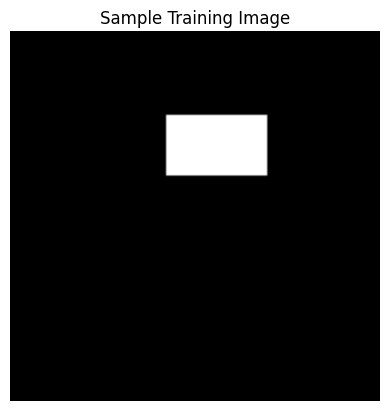

In [2]:
plt.imshow(X[0])
plt.title("Sample Training Image")
plt.axis("off")
plt.show()

In [3]:
# ----------------------------------------
# 2. Train / Test Split
# ----------------------------------------

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [4]:
# ----------------------------------------
# 3. Build a YOLO-like CNN Model
# ----------------------------------------

model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        16,
        (3, 3),
        activation='relu',
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    # Output: bounding box + class
    tf.keras.layers.Dense(5, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,989 (6.22 MB)

 Trainable params: 1,629,989 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ----------------------------------------
# 4. Train Model
# ----------------------------------------

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0177 - val_loss: 0.0043
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.5835e-04 - val_loss: 0.0016
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.6106e-04 - val_loss: 0.0015
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2700e-04 - val_loss: 0.0015
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1799e-04 - val_loss: 0.0014
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6980e-04 - val_loss: 0.0013
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3601e-04 - val_loss: 0.0014


In [6]:
# ----------------------------------------
# 5. Evaluate Model
# ----------------------------------------

loss = model.evaluate(X_test, y_test)

print("Test Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - loss: 0.0014
Test Loss: 0.0013590127928182483


In [7]:
# ----------------------------------------
# 6. IoU (Intersection over Union)
# ----------------------------------------

def IoU(box1, box2):

    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    x1_min = x1 - w1 / 2
    x1_max = x1 + w1 / 2
    y1_min = y1 - h1 / 2
    y1_max = y1 + h1 / 2

    x2_min = x2 - w2 / 2
    x2_max = x2 + w2 / 2
    y2_min = y2 - h2 / 2
    y2_max = y2 + h2 / 2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_area = max(0, inter_xmax - inter_xmin) * max(
        0, inter_ymax - inter_ymin
    )

    area1 = w1 * h1
    area2 = w2 * h2

    union = area1 + area2 - inter_area

    return inter_area / union

In [8]:
# ----------------------------------------
# 7. Test Predictions
# ----------------------------------------

preds = model.predict(X_test[:5])

for i in range(5):

    pred_box = preds[i][:4]
    true_box = y_test[i][:4]

    iou = IoU(pred_box, true_box)

    print("\nExample", i + 1)
    print("True Box:", true_box)
    print("Pred Box:", pred_box)
    print("IoU:", iou)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step

Example 1
True Box: [0.3125    0.6484375 0.296875  0.265625 ]
Pred Box: [0.28126147 0.64443433 0.29253623 0.23387365]
IoU: 0.7193662668736306

Example 2
True Box: [0.36328125 0.34375    0.2578125  0.296875  ]
Pred Box: [0.36675456 0.3280777  0.23316787 0.25587222]
IoU: 0.7794965398081345

Example 3
True Box: [0.76953125 0.390625   0.2734375  0.25      ]
Pred Box: [0.7647185  0.390677   0.26970884 0.1499263 ]
IoU: 0.5813019647073909

Example 4
True Box: [0.6328125  0.41796875 0.171875   0.2734375 ]
Pred Box: [0.61589706 0.4108541  0.26699865 0.23388676]
IoU: 0.5805350225149776

Example 5
True Box: [0.3359375 0.7734375 0.265625  0.21875  ]
Pred Box: [0.32685155 0.76273304 0.24456178 0.24365492]
IoU: 0.8333490593848201
